# 08. 지도학습 기반 종목 추천 (메인 트랙, 10년)
랜덤포레스트/로지스틱회귀/XGBoost 세 모델을 각각 학습시켜, **세 모델이 모두 "이 종목이 다음 리밸런싱까지 같은 시점 종목들의 중앙값보다 나을 것"이라고 동의하는 종목**을 추천 종목으로 삼는다.

## y(정답 라벨)를 왜 "같은 날짜 대비 상대 수익률"로 정했는가
06/07번 노트북에서 원금 수익률 자체가 시장 수익률과 강한 음의 상관관계(-0.5~-0.7)를 보인다는 걸 확인했다. 즉 raw forward return을 그대로 y로 쓰면 모델이 "종목을 고르는 법"이 아니라 "시장이 오를지 내릴지"를 배우게 될 위험이 크다. 그래서 **같은 리밸런싱 날짜 안에서 중앙값보다 나았는지**로 이진화해서, 그 시점의 시장 국면을 자동으로 통제한다.

## 왜 30일 리밸런싱을 기준으로 했는가
지도학습은 시점(표본) 수가 많을수록 train/test 분할이 안정적이다. 30일 간격은 86개 시점(60일 42개, 120일 20개, 252일 9개보다 훨씬 많음)으로 가장 데이터가 풍부해 메인 트랙 기준으로 골랐다.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path('/Users/choedasom/lab_middle_project')
assert (PROJECT_ROOT / 'src' / 'ml_selection.py').is_file(), f'경로 확인 필요: {PROJECT_ROOT}'
if str(PROJECT_ROOT) not in sys.path: sys.path.insert(0, str(PROJECT_ROOT))

for m in list(sys.modules):
    if m == 'src' or m.startswith('src.'):
        del sys.modules[m]

import pandas as pd
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

from src.performance import add_forward_returns
from src.ml_selection import add_relative_label, time_split, train_models, predict_all, FEATURE_METRICS

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
final_df = pd.read_parquet(PROCESSED_DIR / 'final_df.parquet')
rebalance_30df = pd.read_parquet(PROCESSED_DIR / 'rebalance_30df.parquet')
print(f'rebalance_30df: {rebalance_30df.shape}')

rebalance_30df: (43084, 6)


## 라벨 구성 및 train/test 시간 분할

In [2]:
feature_cols = [f'{m}_30d' for m in FEATURE_METRICS]

perf = add_forward_returns(rebalance_30df, final_df)
perf = perf.dropna(subset=[*feature_cols, 'forward_return'])  # 워밍업 구간 + 마지막 시점(다음 값 없음) 제외
labeled = add_relative_label(perf)

print(f'전체: {labeled.shape}, {labeled["Date"].nunique()}개 시점')
print(labeled['outperform_peers'].value_counts(normalize=True).round(3))

train_dates, test_dates = time_split(labeled['Date'].unique().tolist(), train_ratio=0.7)
print(f'train: {len(train_dates)}개 시점 ({min(train_dates).date()} ~ {max(train_dates).date()})')
print(f'test:  {len(test_dates)}개 시점 ({min(test_dates).date()} ~ {max(test_dates).date()})')

train = labeled[labeled['Date'].isin(train_dates)]
test = labeled[labeled['Date'].isin(test_dates)].copy()
X_train, y_train = train[feature_cols], train['outperform_peers']
X_test, y_test = test[feature_cols], test['outperform_peers']
print(f'train rows: {len(X_train)}, test rows: {len(X_test)}')

전체: (42041, 9), 86개 시점
outperform_peers
0    0.5
1    0.5
Name: proportion, dtype: float64
train: 60개 시점 (2016-02-17 ~ 2023-02-28)
test:  26개 시점 (2023-04-12 ~ 2026-04-09)
train rows: 29107, test rows: 12934


## 모델 3개 학습 및 개별 성능

In [3]:
fitted = train_models(X_train, y_train)
preds = predict_all(fitted, X_test)

for name in ['random_forest', 'logistic', 'xgboost']:
    acc = accuracy_score(y_test, preds[name])
    auc = roc_auc_score(y_test, preds[name])
    print(f'{name:15s} accuracy={acc:.3f}  AUC={auc:.3f}  (0.5=랜덤과 동일)')

random_forest   accuracy=0.492  AUC=0.491  (0.5=랜덤과 동일)
logistic        accuracy=0.491  AUC=0.491  (0.5=랜덤과 동일)
xgboost         accuracy=0.494  AUC=0.494  (0.5=랜덤과 동일)


## Walk-forward 검증 — 70/30 분할 하나로는 부족하다
방금 본 정확도·AUC는 딱 한 번의 시간 분할(train 2016~2023 / test 2023~2026) 결과다. 그 test 구간 하나가 우연히 예측하기 쉽거나 어려운 특수한 시기였을 수 있어서, "예측력이 없다"는 결론을 이 한 번의 분할만으로 내리는 건 근거가 약하다.

그래서 연도별로 다음 해를 예측하는 expanding-window walk-forward로 반복 검증한다: `train 2016~2020 → test 2021`, `train 2016~2021 → test 2022`, ... 매 fold마다 그 해 이전 데이터로만 학습하고 그 해만 평가하므로 미래 정보 유출이 없고, 결론이 특정 연도에만 해당하는지 전체 기간에 걸쳐 일관되는지 바로 확인된다.

In [4]:
from src.ml_selection import walk_forward_splits

splits = walk_forward_splits(labeled['Date'].unique().tolist(), min_train_years=5)
print(f'{len(splits)}개 fold')

rows = []
for train_dates, test_dates in splits:
    fold_train = labeled[labeled['Date'].isin(train_dates)]
    fold_test = labeled[labeled['Date'].isin(test_dates)]
    X_tr, y_tr = fold_train[feature_cols], fold_train['outperform_peers']
    X_te, y_te = fold_test[feature_cols], fold_test['outperform_peers']

    fold_fitted = train_models(X_tr, y_tr)
    fold_preds = predict_all(fold_fitted, X_te)

    test_year = min(test_dates).year
    for name in ['random_forest', 'logistic', 'xgboost']:
        rows.append({
            'test_year': test_year,
            'model': name,
            'n_train_dates': len(train_dates),
            'n_test_dates': len(test_dates),
            'accuracy': accuracy_score(y_te, fold_preds[name]),
            'auc': roc_auc_score(y_te, fold_preds[name]),
        })

wf_results = pd.DataFrame(rows)
wf_results.pivot(index='test_year', columns='model', values='auc').round(3)

6개 fold


model,logistic,random_forest,xgboost
test_year,,,
2021,0.512,0.502,0.495
2022,0.491,0.507,0.488
2023,0.486,0.492,0.484
2024,0.490,0.485,0.498
2025,0.525,0.494,0.507
2026,0.524,0.516,0.509


              accuracy                         auc                     
                  mean    std    min    max   mean    std    min    max
model                                                                  
logistic         0.505  0.018  0.486  0.525  0.504  0.018  0.486  0.525
random_forest    0.500  0.011  0.485  0.516  0.499  0.011  0.485  0.516
xgboost          0.497  0.010  0.485  0.509  0.497  0.010  0.484  0.509


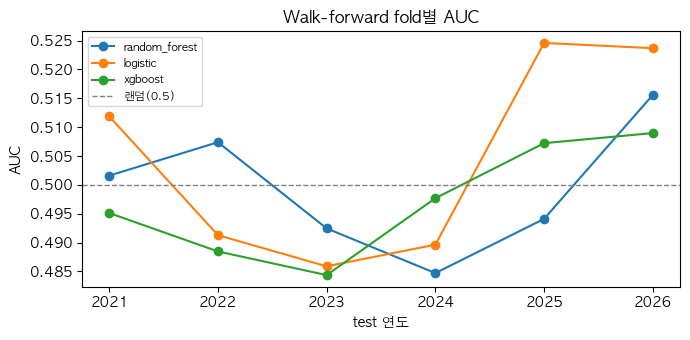

In [5]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

summary = wf_results.groupby('model')[['accuracy', 'auc']].agg(['mean', 'std', 'min', 'max'])
print(summary.round(3))

fig, ax = plt.subplots(figsize=(7, 3.5))
for name in ['random_forest', 'logistic', 'xgboost']:
    sub = wf_results[wf_results['model'] == name]
    ax.plot(sub['test_year'], sub['auc'], marker='o', label=name)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='랜덤(0.5)')
ax.set_xlabel('test 연도')
ax.set_ylabel('AUC')
ax.set_title('Walk-forward fold별 AUC')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

**결론 — 단일 분할 결과가 그대로 재확인됐다.** 6개 fold(2021~2026) 전부 AUC가 0.484~0.525 사이, 평균은 세 모델 다 0.497~0.505로 0.5에서 거의 안 벗어난다. fold별 표준편차도 0.010~0.018로 작아서, 특정 연도만 우연히 예측이 잘/안 됐던 게 아니라 **모든 해에 걸쳐 일관되게 예측력이 없다**. 앞선 70/30 단일 분할 결론("동전 던지기와 동일")이 운 좋은/나쁜 test 구간 하나 때문이 아니었음을 확인했다.

## 피처 중요도 (Random Forest)

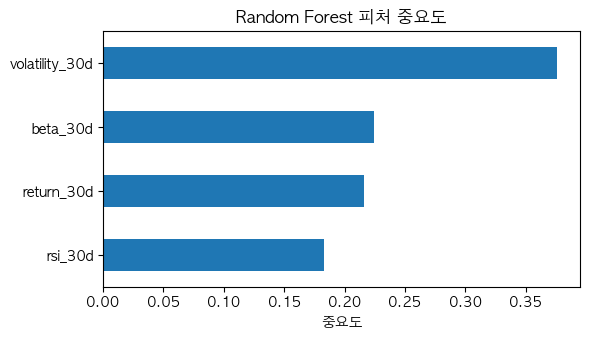

In [6]:
rf = fitted['models']['random_forest']
importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(6, 3.5))
importance.plot.barh(ax=ax, color='#1f77b4')
ax.set_xlabel('중요도')
ax.set_title('Random Forest 피처 중요도')
plt.tight_layout()
plt.show()

## 합의 추천(consensus) 종목 백테스트
세 모델이 모두 "outperform"이라고 예측한 종목만 골라서, 실제 다음 시점까지 수익률이 나머지 종목들과 어떻게 달랐는지 확인한다.

In [7]:
test['consensus'] = preds['consensus'].values
print(f'합의 추천 비율: {test["consensus"].mean():.1%}')

backtest = test.groupby('consensus')['forward_return'].agg(n='count', mean='mean', std='std')
backtest['return_per_risk'] = backtest['mean'] / backtest['std']
backtest.rename(index={True: '합의 추천', False: '나머지'})

합의 추천 비율: 21.6%


,n,mean,std,return_per_risk
consensus,,,,
나머지,10134,0.018303,0.109577,0.167030
합의 추천,2800,0.009454,0.091953,0.102808


## 결론 — 정직하게, 예측력이 없다
세 모델 모두 정확도·AUC가 **0.49~0.50 — 동전 던지기와 사실상 동일**하다. 합의 추천 종목의 실제 백테스트 성과도 나머지보다 **더 낮았다**(평균 수익률·위험 대비 수익률 둘 다).

이건 구현 실수가 아니라 예상 가능한 결과에 가깝다 — beta/volatility/return/rsi 4개는 원래 "안정성 vs 수익률" 팩터를 나누기 위해 고른 지표였지, "이 종목이 다른 종목보다 앞으로 잘 나갈지"를 맞추는 예측 신호로 검증된 적이 없었다. 게다가 같은 4개 지표로 계산된 값들이라 모델이 학습할 수 있는 새로운 정보가 애초에 많지 않다.

**다음 단계**: 이 결과가 바로 PER 같은 재무지표(밸류에이션 정보)를 추가해볼 근거가 된다 — 가격 기반 지표만으로는 예측력이 없다는 게 확인됐으니, 완전히 다른 정보원(재무제표)이 실제로 신호를 더할 수 있는지가 다음에 검증할 질문이다. 최근 5년 구간에서 PER 포함/미포함 모델을 나란히 비교하는 09번 노트북으로 이어간다.